## 🔧 Environment Setup & Checkpoint Loading

_Added to fix the cross-notebook data-flow issue: this cell imports the common libraries this notebook needs, and defines helper functions to save/load intermediate results so this notebook works correctly whether it's run right after the previous one or on its own, days later, after the raw data has changed._

In [1]:
# 🔧 SETUP: local paths, common imports & checkpoint utilities
# This cell fixes the "notebook 2 can't see notebook 1's data" problem: instead
# of relying on variables still sitting in memory from another notebook (which
# never works once notebooks are split into separate .ipynb files, or run in
# separate VS Code kernels), every notebook loads what it needs from a shared
# "checkpoints" folder on disk, and saves what later notebooks need back to
# that same folder.

import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# 📁 Data lives in a `data` folder that's a *sibling* of the folder these
# notebooks are run from (e.g. `project/notebooks/*.ipynb` + `project/data/`).
# This resolves the same way no matter whose machine it runs on - no
# usernames or absolute paths baked in. Adjust the '..' below if your data
# folder sits somewhere else relative to your notebooks.
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'data'))
DATA_DIR = BASE_DIR
CKPT_DIR = os.path.join(BASE_DIR, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)


def save_ckpt(obj, name):
    """Save a variable to the shared checkpoint folder so later notebooks can load it."""
    path = os.path.join(CKPT_DIR, f'{name}.pkl')
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f"✅ Saved checkpoint '{name}' -> {path}")


def load_ckpt(name):
    """Load a variable that was saved by an earlier notebook in this pipeline."""
    path = os.path.join(CKPT_DIR, f'{name}.pkl')
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"❌ Checkpoint '{name}' not found at {path}.\n"
            f"   Make sure you have run the earlier notebook(s) in the pipeline first "
            f"(they save this checkpoint at their final cell), and that BASE_DIR "
            f"above points at the right folder."
        )
    with open(path, 'rb') as f:
        obj = pickle.load(f)
    print(f"✅ Loaded checkpoint '{name}' <- {path}")
    return obj


C:\Users\arushi khare\AppData\Local\Temp\ipykernel_38836\1428146299.py:11: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## 📥 Load Checkpoints From Earlier Notebooks

In [2]:
# 📥 Load the variables this notebook needs from earlier notebooks in the pipeline
final_df = load_ckpt('part3_final_df')


✅ Loaded checkpoint 'part3_final_df' <- c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part3_final_df.pkl


### **🔁Re-Evaluating Anomalies in Transformed Weekly Sales (Post-Outlier Treatment)**

We reapply anomaly detection using the Z-score method on the square root transformed Weekly_Sales after the previous outlier treatment. This helps ensure that extreme values are minimized and only statistically significant anomalies remain.

In [3]:
import numpy as np

# Calculate mean and standard deviation for the square root transformed sales
mean_sales = np.mean(final_df['Sales_sqrt'])
std_deviation = np.std(final_df['Sales_sqrt'])

# Define a threshold for anomalies (3 standard deviations above the mean)
threshold = mean_sales + 3 * std_deviation

# Identify anomalies
anomalies = [x for x in final_df['Sales_sqrt'] if x > threshold]

# Flag anomalies in the cleaned DataFrame
final_df['Anomaly'] = final_df['Sales_sqrt'].apply(lambda x: 1 if x > threshold else 0)

# Print anomaly statistics
print("📊 Retail Weekly Sales Data (Post-Outlier Treatment):")
print("Mean Sales (sqrt):", round(mean_sales, 2))
print("Standard Deviation (sqrt):", round(std_deviation, 2))
print("Total Number of Anomalies:", len(anomalies))
print("Percentage of Anomalies:", round((len(anomalies)/len(final_df)) * 100, 2), "%")

📊 Retail Weekly Sales Data (Post-Outlier Treatment):
Mean Sales (sqrt): 0.14
Standard Deviation (sqrt): 0.05
Total Number of Anomalies: 0
Percentage of Anomalies: 0.0 %


# **⏳ Time-Based Anomaly Detection**

Analyze sales trends over time to uncover hidden insights, understand seasonality, and detect deviations.

---

### 🎯 Objectives:

- Understand how **sales evolve over time**.
- Detect **seasonal variations** and **holiday effects**.
- Apply **time-series analysis** to evaluate store and department performance.
- Identify **anomalies in sales patterns** using temporal methods.

---

### 💡 Approach:

#### 📊 Create Rolling Statistics
- Calculate **rolling averages**, **moving sums**, and **rolling standard deviations**.
- Helps in understanding fluctuations and identifying local trends over time.

#### 🔄 Apply Exponential Smoothing
- Use **Exponential Moving Averages (EMA)** to give more weight to recent observations.
- Reveals **sudden spikes or drops** which may indicate anomalies.

#### 🚨 Highlight Anomalies
- Define **thresholds** based on statistical deviations.
- Use **visual cues** (e.g., shaded regions or red markers) to flag points that significantly diverge from expected patterns.

---

**🧠 Insight:**  
Time-based anomaly detection enables early identification of irregular patterns like **sales dips**, **promotional peaks**, or **operational issues**. Leveraging time series analytics supports **proactive decision-making** and **forecast accuracy**.

# 📈 Rolling Statistics for Time-Based Anomaly Detection

To detect unusual sales behavior over time, we apply **rolling averages** on weekly sales data. This helps smooth out short-term fluctuations and highlight longer-term trends or anomalies.

### 🔍 Approach:

- **Step 1:** Sort the dataset chronologically by `Date` to ensure accurate time-series calculation.
- **Step 2:** Compute a **30-day rolling average** of `Weekly_Sales` to identify expected sales behavior.
- **Step 3:** Flag data points as anomalies where the actual weekly sales are **significantly lower** than the rolling average.

This method enables early detection of unexpected dips in sales, which may indicate issues like:
- Supply chain disruptions
- Store closures
- Poor-performing promotions

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 📌 Step 1: Ensure data is sorted by date for time-series analysis
final_df.sort_values(by='Date', inplace=True)

# 📌 Step 2: Set the rolling window size (e.g., 50 weeks)
rolling_window = 50

# 📌 Step 3: Calculate the rolling average of Weekly_Sales
final_df['RollingAvgTotalSales'] = final_df['Weekly_Sales'].rolling(window=rolling_window).mean()

# 📌 Step 4: Set threshold factor (you can tune this)
threshold_factor = 1.0

# 📌 Step 5: Identify anomalies (sales significantly below rolling average)
final_df['SalesAnomaly'] = final_df['Weekly_Sales'] < (threshold_factor * final_df['RollingAvgTotalSales'])


In [5]:
final_df.head(2)
final_df[final_df['SalesAnomaly'] == True]

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,...,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Weekly_Sales_normalized,Sales_sqrt,Anomaly,RollingAvgTotalSales,SalesAnomaly
299120,31,41,2010-02-05,933.00,False,A,203750,NaN,NaN,4209.35,...,15.84,989.08,3030.79,NaN,NaN,0.008483,0.092104,0,8629.1508,True
299263,31,42,2010-02-05,4596.97,False,A,203750,NaN,NaN,4209.35,...,15.84,989.08,3030.79,NaN,NaN,0.013732,0.117182,0,8681.5350,True
299406,31,44,2010-02-05,2278.65,False,A,203750,NaN,NaN,4209.35,...,15.84,989.08,3030.79,NaN,NaN,0.010411,0.102033,0,8289.3406,True
299725,31,47,2010-02-05,86.00,False,A,203750,NaN,NaN,4209.35,...,15.84,989.08,3030.79,NaN,NaN,0.007270,0.085263,0,7973.7500,True
23314,3,22,2010-02-05,4508.20,False,B,37392,NaN,NaN,4209.35,...,15.84,989.08,3030.79,NaN,NaN,0.013604,0.116638,0,7890.9250,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36443,4,56,2012-10-26,567.52,False,A,205863,63.64,3.514,1763.13,...,66.76,989.08,7577.14,131.193097,3.879,0.007960,0.089216,0,12389.7994,True
399499,43,11,2012-10-26,397.39,False,C,41062,69.17,3.506,23.68,...,6.00,989.08,815.05,214.741539,8.839,0.007716,0.087840,0,12393.1492,True
228584,24,12,2012-10-26,4192.44,False,A,203819,55.16,4.071,10844.38,...,105.09,1795.68,3059.80,138.728161,8.693,0.013152,0.114683,0,12032.9244,True
366680,39,44,2012-10-26,6213.29,False,A,184109,72.90,3.506,6057.96,...,159.00,602.37,3392.16,222.113657,6.228,0.016047,0.126677,0,11639.5068,True


C:\Users\arushi khare\AppData\Local\Temp\ipykernel_38836\583006986.py:31: UserWarning: Glyph 128338 (\N{CLOCK FACE THREE OCLOCK}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128338 (\N{CLOCK FACE THREE OCLOCK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


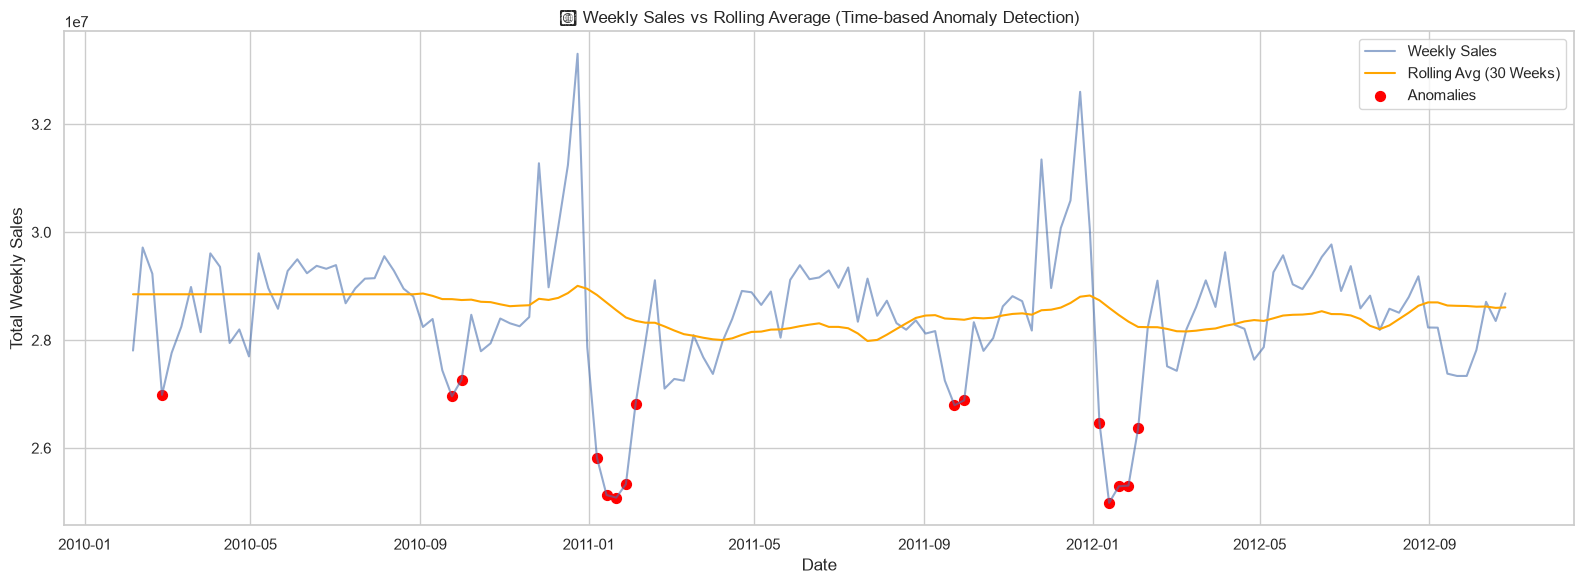

In [6]:
import matplotlib.pyplot as plt

# Step 1: Aggregate Weekly Sales by Date
sales_by_date = final_df.groupby('Date')['Weekly_Sales'].sum().reset_index()

# Step 2: Compute Rolling Average
rolling_window = 30
sales_by_date['RollingAvgTotalSales'] = sales_by_date['Weekly_Sales'].rolling(window=rolling_window).mean()

# Step 3: Fill initial NaNs in rolling avg (optional: with expanding mean or forward fill)
sales_by_date['RollingAvgTotalSales'] = sales_by_date['RollingAvgTotalSales'].bfill()

# Step 4: Detect anomalies using a tighter threshold (e.g., 95%)
threshold_multiplier = 0.95
sales_by_date['SalesAnomaly'] = sales_by_date['Weekly_Sales'] < threshold_multiplier * sales_by_date['RollingAvgTotalSales']

# Step 5: Plotting
plt.figure(figsize=(16, 6))
plt.plot(sales_by_date['Date'], sales_by_date['Weekly_Sales'], label='Weekly Sales', alpha=0.6)
plt.plot(sales_by_date['Date'], sales_by_date['RollingAvgTotalSales'], label='Rolling Avg (30 Weeks)', color='orange')

# Highlight anomalies
anomalies = sales_by_date[sales_by_date['SalesAnomaly']]
plt.scatter(anomalies['Date'], anomalies['Weekly_Sales'], color='red', label='Anomalies', s=50)

plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.title("🕒 Weekly Sales vs Rolling Average (Time-based Anomaly Detection)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 📌 **Observations – Time-Based Anomaly Detection Using Aggregated Weekly Sales**

- The graph displays **total weekly sales** across all stores along with a **30-week rolling average**, providing a smoothed trend over time.

- The **orange line** (rolling average) captures the underlying trend of weekly sales, making it easier to detect deviations from expected patterns.

- **Red dots** indicate weeks where the total weekly sales were significantly **below 95%** of the rolling average — these are flagged as **potential anomalies**.

- These anomalies might be associated with:
  - 🔻 Unexpected drops in sales activity
  - 📆 Seasonality or off-peak weeks
  - 🌦️ External factors such as holidays, weather events, or economic shifts

- Using aggregated sales by date ensures **clearer trend visibility** and avoids the clutter caused by department- or store-level noise.

- This approach is useful for **monitoring overall business health**, identifying **underperformance periods**, and taking **data-driven actions**.


In [7]:
sales_by_date.head(2)

,Date,Weekly_Sales,RollingAvgTotalSales,SalesAnomaly
0,2010-02-05,27806707.31,2.884946e+07,False
1,2010-02-12,29716374.65,2.884946e+07,False


## **Time Series Decomposition of Weekly Sales**

C:\Users\arushi khare\AppData\Local\Temp\ipykernel_38836\4091194944.py:22: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


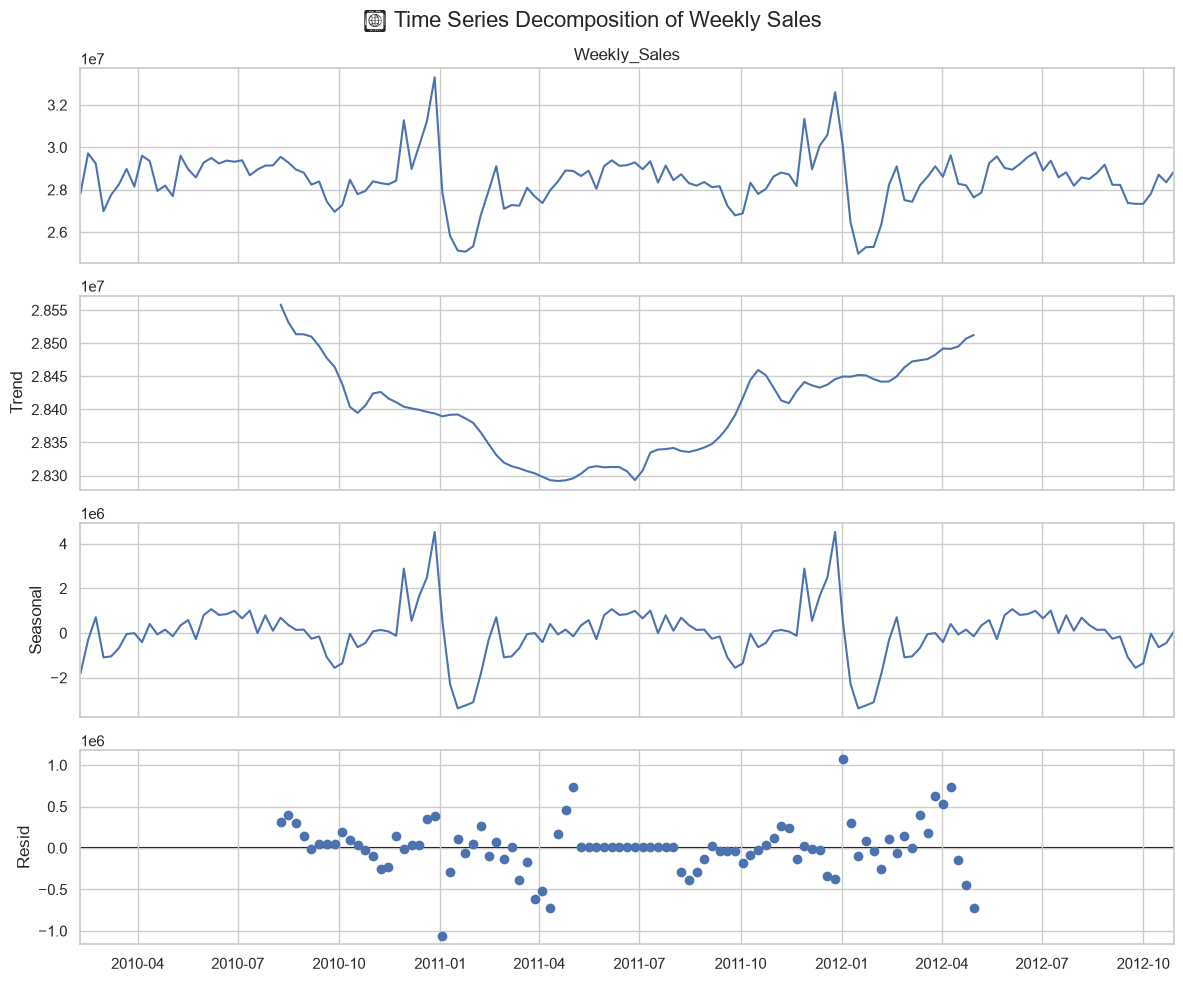

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Step 1: Set Date column as datetime index
sales_by_date['Date'] = pd.to_datetime(sales_by_date['Date'])
sales_by_date.set_index('Date', inplace=True)

# Step 2: Resample to ensure continuous weekly data (fill missing weeks with NaN)
sales_weekly = sales_by_date.resample('W-MON').sum()

# Step 3: Fill missing sales values (to avoid NaNs in decomposition)
sales_weekly['Weekly_Sales'] = sales_weekly['Weekly_Sales'].interpolate(method='linear')

# Step 4: Perform seasonal decomposition
decomposition = seasonal_decompose(sales_weekly['Weekly_Sales'], model='additive', period=52)  # Weekly data, so period ~ 52

# Step 5: Plot
plt.rcParams.update({'figure.figsize': (12, 10)})
decomposition.plot()
plt.suptitle('📉 Time Series Decomposition of Weekly Sales', fontsize=16)
plt.tight_layout()
plt.show()


### 📊 Time Series Decomposition - Weekly Sales

The time series decomposition separates Weekly Sales into three components:

- **Trend**: Reflects the overall upward or downward direction in sales over time.
- **Seasonality**: Shows repeated patterns in sales at regular intervals (e.g., yearly or seasonal effects).
- **Residual**: Captures random noise or anomalies not explained by trend or seasonality.

From the decomposition plot:

- The **trend** appears stable with mild upward movement in some periods.
- The **seasonality** component indicates consistent repeating sales patterns likely influenced by holidays or seasonal demand.
- The **residuals** show some significant fluctuations, which may signal potential anomalies or events such as promotions or unexpected external factors.

This breakdown helps in understanding and forecasting sales more accurately by isolating patterns and irregularities.


## ⚙️ Exponentially Weighted Moving Average (EWMA) for Weekly Sales

In this step, we apply **Exponentially Weighted Moving Average (EWMA)** with a smoothing factor (α = 0.2) to highlight recent changes in weekly sales more effectively than older values.

---

### ✅ Approach:
- The **EWMA line (α = 0.2)** is calculated to smooth out fluctuations in Weekly Sales, emphasizing recent observations.
- An **anomaly is flagged** when the actual Weekly Sales fall **significantly below** the EWMA trend.
- A **threshold of 95%** of the EMA is used to mark deviations as anomalies.

---

### 🔍 Objective:
- Detect **recent drops in sales** that may signal emerging issues or shifts in customer behavior.
- Highlight **unusual downward patterns** using a dynamic, time-sensitive baseline.
- Help uncover potential drivers such as markdowns, stockouts, or demand changes.

---

### 📉 Visualization:
- The **orange dashed line** represents the EWMA trend.
- **Red dots** indicate detected anomalies — periods where actual sales dropped well below the expected smoothed trend.


C:\Users\arushi khare\AppData\Local\Temp\ipykernel_38836\1025730299.py:32: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


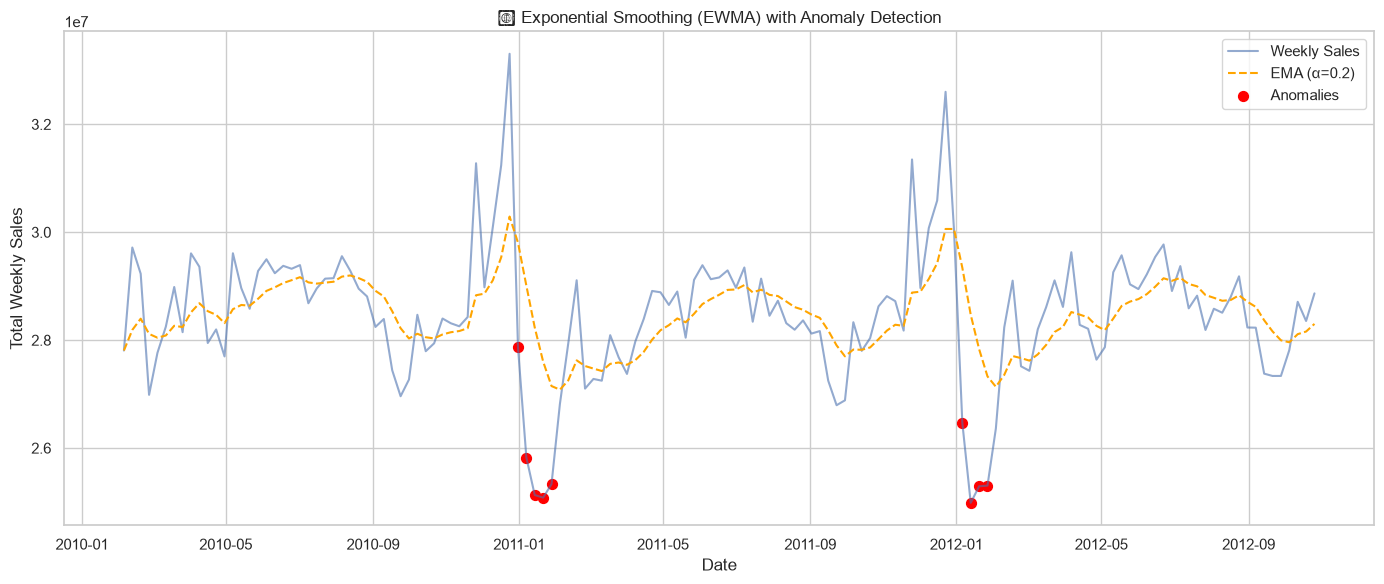

In [9]:
import matplotlib.pyplot as plt

# Step 1: Aggregate data if there are multiple records per date
sales_by_date = final_df.groupby('Date')['Weekly_Sales'].sum().reset_index()

# Step 2: Sort by Date
sales_by_date = sales_by_date.sort_values(by='Date')

# Step 3: Apply EWMA
alpha = 0.2
sales_by_date['EMAWeeklySales'] = sales_by_date['Weekly_Sales'].ewm(alpha=alpha, adjust=False).mean()

# Step 4: Identify anomalies (sales significantly below EMA)
threshold_multiplier = 0.95
sales_by_date['SalesAnomaly_EMA'] = sales_by_date['Weekly_Sales'] < threshold_multiplier * sales_by_date['EMAWeeklySales']

# Step 5: Plot the data
plt.figure(figsize=(14, 6))
plt.plot(sales_by_date['Date'], sales_by_date['Weekly_Sales'], label='Weekly Sales', alpha=0.6)
plt.plot(sales_by_date['Date'], sales_by_date['EMAWeeklySales'], label='EMA (α=0.2)', linestyle='--', color='orange')

# Highlight anomalies in red
anomalies = sales_by_date[sales_by_date['SalesAnomaly_EMA']]
plt.scatter(anomalies['Date'], anomalies['Weekly_Sales'], color='red', label='Anomalies', s=50)

# Final plot touches
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.title('📉 Exponential Smoothing (EWMA) with Anomaly Detection')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 📌 Observations from EWMA-Based Anomaly Detection

- The **Exponentially Weighted Moving Average (EWMA)** of the sales data shows a **mostly steady trend** over time, with occasional fluctuations.
- This indicates that overall weekly sales have remained relatively stable, apart from **a few short-term changes** likely due to external factors.
- A number of **anomalies (red dots)** were detected, representing **sudden drops in sales** compared to the smoothed EWMA line.
- These anomalies may be attributed to:
  - **Special holidays** or events.
  - **Seasonal demand fluctuations**.
  - **Unexpected disruptions** (e.g., stockouts, logistics issues, or external economic events).


## 🧩 Customer Segmentation Analysis using PCA & Clustering

Customer segmentation was performed on **store-level** and **department-level** aggregated sales data to identify distinct behavioral clusters based on sales patterns, markdowns, and regional attributes.

---

### 🔍 Step 1: Data Aggregation

- Aggregated key performance metrics such as **Weekly Sales**, **Markdown1–5**, **CPI**, **Size**, **Temperature**, and **Unemployment**.
- Computed **mean values** grouped by both `Store` and `Dept`.
- This helped summarize long-term performance and allowed for clustering across meaningful segments.

---

### ⚖️ Step 2: Feature Normalization & Transformation

- Applied **MinMaxScaler** to normalize numerical features in the 0–1 range.
- Performed **Square Root Transformation** on normalized features to reduce skewness, making them suitable for clustering algorithms.

---

### 🧪 Step 3: Dimensionality Reduction with PCA

- Performed **Principal Component Analysis (PCA)** to reduce the dimensionality while preserving most of the variance.
- Used PCA for both store-level (`store_df`) and department-level (`dept_df`) aggregated datasets.
- Based on the **explained variance curve**, selected **3 principal components**, which captured a significant portion of the total variance.

---

### 📉 PCA Insights:

- PCA allows better visualization and performance of clustering algorithms.
- Helps avoid overfitting and speeds up training.

---

### 📌 Step 4: Elbow Method for Optimal Clusters

- Applied **KMeans clustering** and plotted the **Elbow Curve** using **WCSS (Within-Cluster Sum of Squares)**.
- Identified the "elbow point" — the optimal number of clusters where the WCSS starts to diminish significantly.

---

### 📊 Step 5: Clustering Stores / Departments

- Ran **KMeans clustering** with the selected number of clusters (e.g., 3 or 4).
- Generated customer/store/department segments based on similar sales and operational behavior.

---

### 📏 Step 6: Segmentation Quality Evaluation — Silhouette Score

- Used **Silhouette Score** to measure the quality of clustering:
  - A higher silhouette score indicates **better cohesion within clusters** and **greater separation between clusters**.
- Visualized the silhouette score for different `k` values ranging from 2 to 6.
- Also plotted the **actual clusters** using PCA-reduced dimensions.

---

### ✅ Benefits of This Segmentation

- Enables **targeted strategies** for each segment — such as promotions, inventory, or staffing.
- Helps in **identifying underperforming stores or departments**.
- Facilitates **region-specific or category-specific decision making**.

---

### 📌 Next Steps

- Use clustering results to **enhance marketing, supply chain, or pricing decisions**.
- Combine segmentation results with **external data** (e.g., demographics, holidays, competition) for even deeper insights.



### Distribution-based feature separation

In [10]:
# ✅ Step 1: Copying clean data for clustering
cluster_df = final_df.copy()

# ✅ Step 2: Define relevant features for segmentation
features = ['Weekly_Sales', 'MarkDown1', 'MarkDown2','MarkDown3','MarkDown4',
            'MarkDown5','CPI','Unemployment','Size','Fuel_Price','Temperature']

# ✅ Step 3: Classify features as symmetric or skewed based on mean-median difference
symmetric_feature = []
non_symmetric_feature = []

for feature in features:
    if abs(cluster_df[feature].mean() - cluster_df[feature].median()) < 0.2:
        symmetric_feature.append(feature)
    else:
        non_symmetric_feature.append(feature)

print("Symmetric Distributed Features:", symmetric_feature)
print("Skewed Distributed Features:", non_symmetric_feature)

Symmetric Distributed Features: ['Unemployment', 'Fuel_Price']
Skewed Distributed Features: ['Weekly_Sales', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Size', 'Temperature']


### Normalization

In [11]:
# ✅ Step 4: Normalize the numeric features using MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
normalized_features = ['Weekly_Sales', 'MarkDown1', 'MarkDown2','MarkDown3','MarkDown4',
                       'MarkDown5','CPI','Size','Temperature','Unemployment', 'Fuel_Price']

# Apply normalization
for col in normalized_features:
    cluster_df[col + '_normalized'] = scaler.fit_transform(cluster_df[[col]])

### Square root transformation

In [12]:
# ✅ Step 5: Apply Square Root Transformation to reduce skewness
sqrt_features = ['Weekly_Sales_normalized','MarkDown1_normalized', 'MarkDown2_normalized',
                 'MarkDown3_normalized','MarkDown4_normalized','MarkDown5_normalized',
                 'CPI_normalized','Size_normalized','Temperature_normalized']

for col in sqrt_features:
    cluster_df[col + '_sqrt'] = cluster_df[col].apply(lambda x: x ** 0.5)


In [13]:
print(cluster_df.columns.tolist())

['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Weekly_Sales_normalized', 'Sales_sqrt', 'Anomaly', 'RollingAvgTotalSales', 'SalesAnomaly', 'MarkDown1_normalized', 'MarkDown2_normalized', 'MarkDown3_normalized', 'MarkDown4_normalized', 'MarkDown5_normalized', 'CPI_normalized', 'Size_normalized', 'Temperature_normalized', 'Unemployment_normalized', 'Fuel_Price_normalized', 'Weekly_Sales_normalized_sqrt', 'MarkDown1_normalized_sqrt', 'MarkDown2_normalized_sqrt', 'MarkDown3_normalized_sqrt', 'MarkDown4_normalized_sqrt', 'MarkDown5_normalized_sqrt', 'CPI_normalized_sqrt', 'Size_normalized_sqrt', 'Temperature_normalized_sqrt']


## 📊 Distribution Plots of Transformed and Normalized Features

To understand the shape and spread of the transformed features, we plotted the distributions of all relevant normalized and square-root-transformed variables. This visualization helps in:

- Validating normalization and transformation steps.
- Checking for skewness, modality, or irregular patterns.
- Gaining insights into the feature behavior before applying clustering.

The histograms below include KDE (Kernel Density Estimation) curves to visualize the underlying probability distribution.

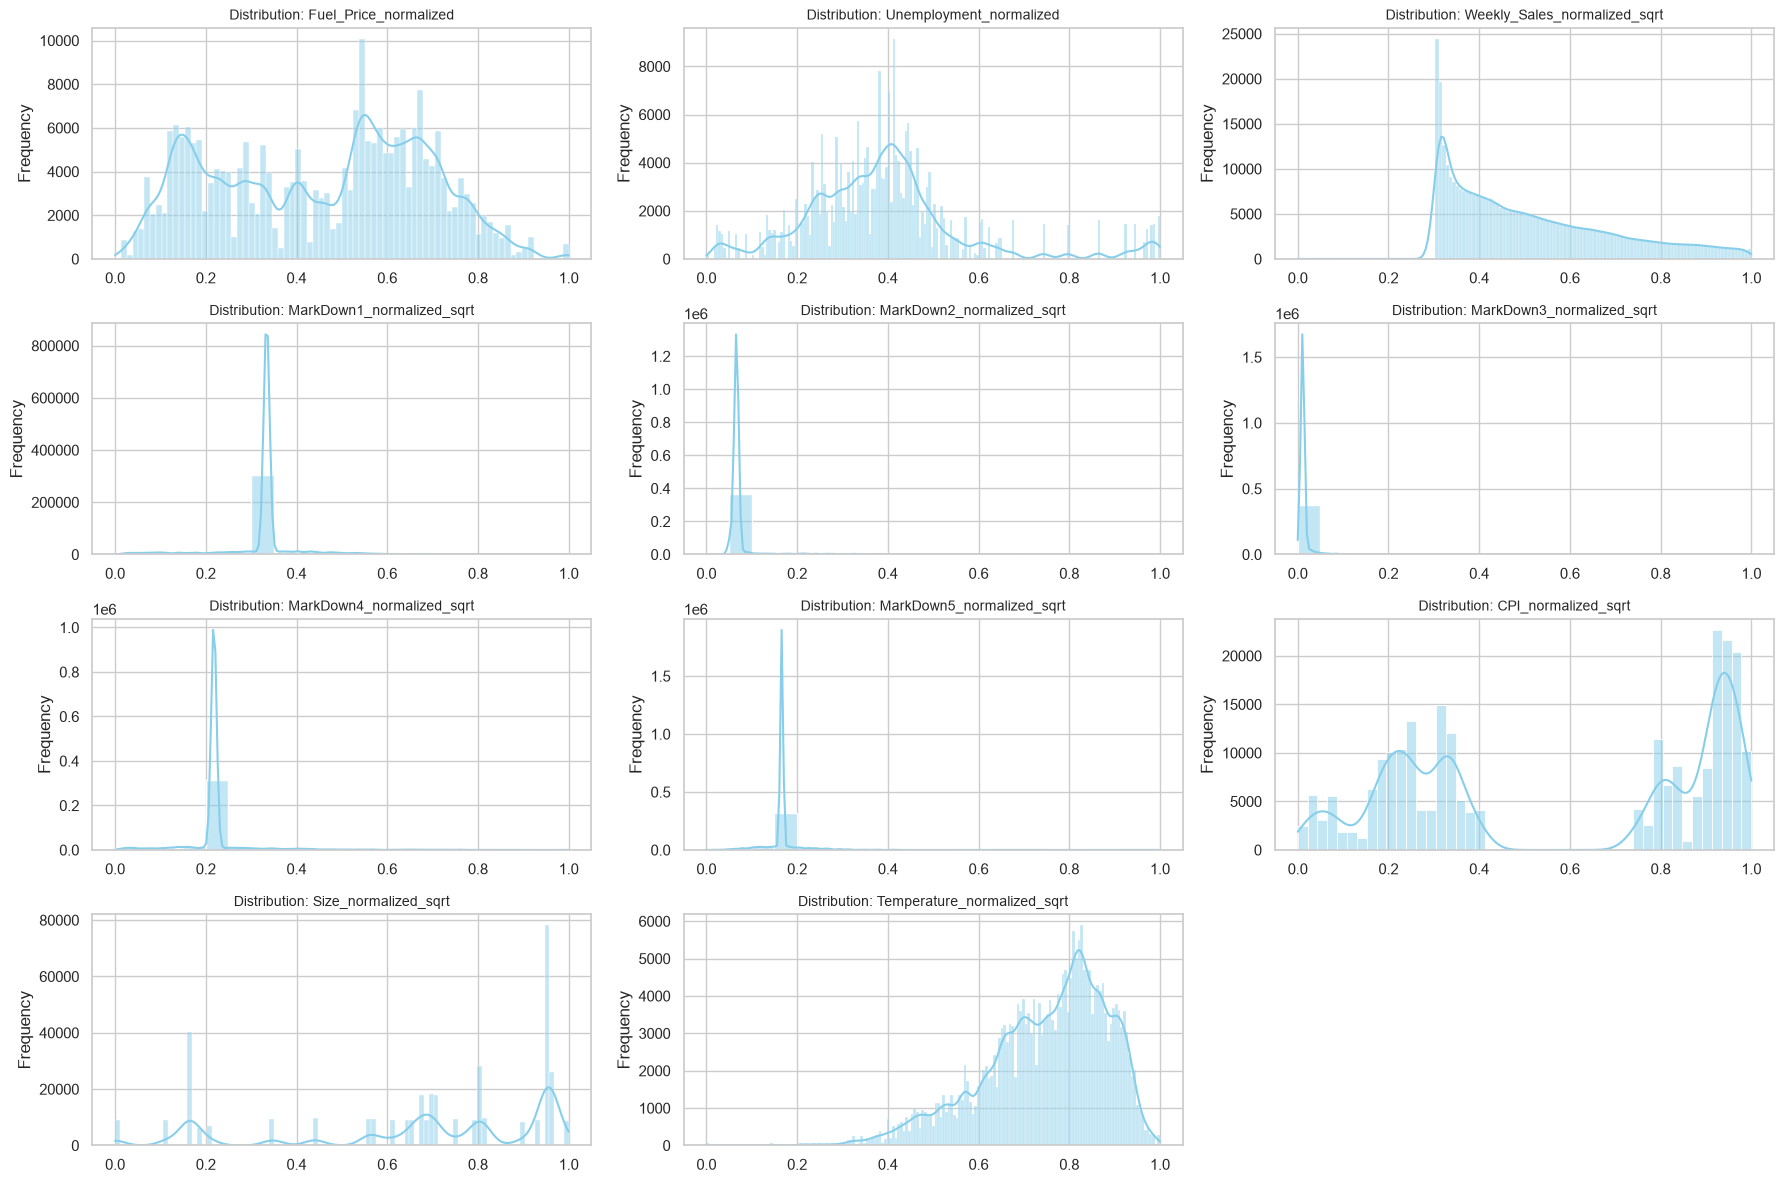

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style for seaborn
sns.set(style="whitegrid")

# Corrected list of transformed feature columns
cols = [
    'Fuel_Price_normalized', 'Unemployment_normalized',
    'Weekly_Sales_normalized_sqrt', 'MarkDown1_normalized_sqrt',
    'MarkDown2_normalized_sqrt', 'MarkDown3_normalized_sqrt',
    'MarkDown4_normalized_sqrt', 'MarkDown5_normalized_sqrt',
    'CPI_normalized_sqrt', 'Size_normalized_sqrt',
    'Temperature_normalized_sqrt'
]

# Define grid layout
n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))
axes = axes.flatten()

# Plot each distribution
for i, col in enumerate(cols):
    sns.histplot(cluster_df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f"Distribution: {col}", fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

# Remove any unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### **Store Wise clustering**

In [15]:
# Define the aggregation functions and rename columns (correct column names with underscores)
agg_functions = {
    'Weekly_Sales_normalized_sqrt': 'mean',
    'MarkDown1_normalized_sqrt': 'mean',
    'MarkDown2_normalized_sqrt': 'mean',
    'MarkDown3_normalized_sqrt': 'mean',
    'MarkDown4_normalized_sqrt': 'mean',
    'MarkDown5_normalized_sqrt': 'mean',
    'CPI_normalized_sqrt': 'mean',
    'Size_normalized_sqrt': 'mean',
    'Temperature_normalized_sqrt': 'mean'
}

# Calculate the mean for each column grouped by 'Store' and reset index
mean_by_store = cluster_df.groupby('Store').agg(agg_functions).reset_index()

# Rename the columns for better readability
mean_by_store.columns = [
    'Store', 'Mean_Weekly_Sales', 'Mean_MarkDown1', 'Mean_MarkDown2',
    'Mean_MarkDown3', 'Mean_MarkDown4', 'Mean_MarkDown5',
    'Mean_CPI', 'Mean_Size', 'Mean_Temperature'
]

# Convert to DataFrame with 'Store' as index
store_df = pd.DataFrame(mean_by_store.set_index('Store'))

# Display the result
store_df.head()

,Mean_Weekly_Sales,Mean_MarkDown1,Mean_MarkDown2,Mean_MarkDown3,Mean_MarkDown4,Mean_MarkDown5,Mean_CPI,Mean_Size,Mean_Temperature
Store,,,,,,,,,
1,0.550465,0.343881,0.077684,0.016432,0.229358,0.171666,0.943453,0.793894,0.812104
2,0.577355,0.357067,0.084773,0.018172,0.242539,0.179336,0.941835,0.951986,0.810601
3,0.417468,0.310131,0.070682,0.014672,0.201481,0.146247,0.961170,0.116722,0.832889
4,0.574286,0.349622,0.082945,0.018904,0.245956,0.180348,0.145126,0.962042,0.768232
5,0.409784,0.305462,0.070648,0.014551,0.201575,0.156021,0.946475,0.000000,0.818892


### 📉 PCA for Dimensionality Reduction

We applied **Principal Component Analysis (PCA)** to reduce the number of features while retaining most of the data's variance.

- PCA helps simplify the dataset for clustering.
- The cumulative variance plot shows how many components are needed.
- We selected **3 components**, which explain a large portion of the variance.
- The dataset was then transformed into this 3D space (`df_pca`) for better analysis and segmentation.

This step prepares the data for effective clustering and visualization.


c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


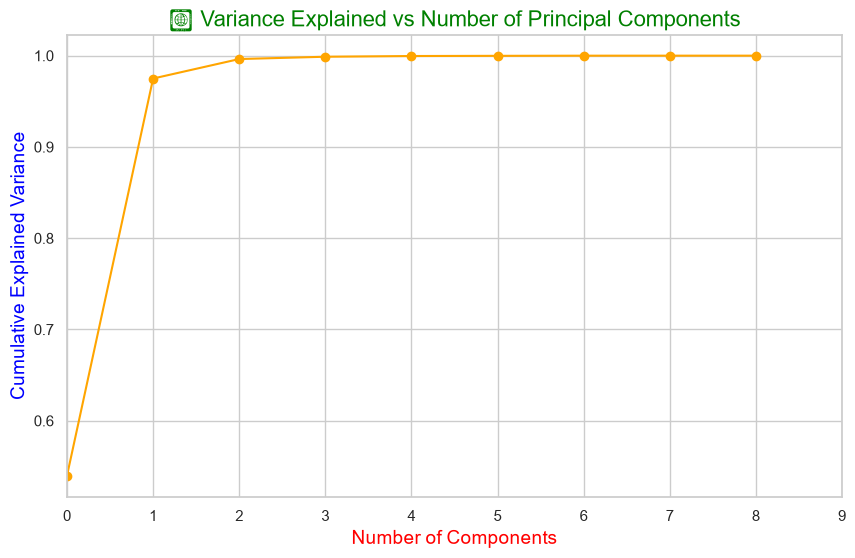

✅ Explained variance per principal component:
[0.53985467 0.43509882 0.02134301]

🔢 Cumulative variance explained by 3 components: 99.63%

Original shape: (45, 9)
Transformed shape: (45, 3)


In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Define features for PCA (already aggregated by Store)
features = store_df.columns

# Step 2: Apply PCA without limiting components (to analyze variance explained)
pca = PCA()
pca.fit(store_df[features])

# Step 3: Plot explained variance vs number of components
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', color='orange')
plt.xlabel('Number of Components', size=14, color='red')
plt.ylabel('Cumulative Explained Variance', size=14, color='blue')
plt.title('🔍 Variance Explained vs Number of Principal Components', size=16, color='green')
plt.grid(True)
plt.xlim([0, len(features)])
plt.show()

# Step 4: Apply PCA with selected number of components (e.g., 3)
pca = PCA(n_components=3)
pca.fit(store_df[features])
df_pca = pca.transform(store_df[features])

# Step 5: Print insights
print("✅ Explained variance per principal component:")
print(pca.explained_variance_ratio_)

print("\n🔢 Cumulative variance explained by 3 components: {:.2%}".format(
    np.sum(pca.explained_variance_ratio_)))

print("\nOriginal shape:", store_df.shape)
print("Transformed shape:", df_pca.shape)

### 📌 **KMeans Clustering** - **Elbow Method**

To determine the optimal number of clusters (**K**) for segmentation, we used the **Elbow Method**:

- Applied **KMeans clustering** for values of K from 1 to 10.
- Computed **WCSS (Within-Cluster Sum of Squares)** for each K.
- Plotted the **Elbow Curve** to visualize the point where WCSS starts to level off.

📍 The "elbow point" indicates the optimal K value, balancing performance and simplicity for clustering.


C:\Users\arushi khare\AppData\Local\Temp\ipykernel_38836\1358707409.py:20: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


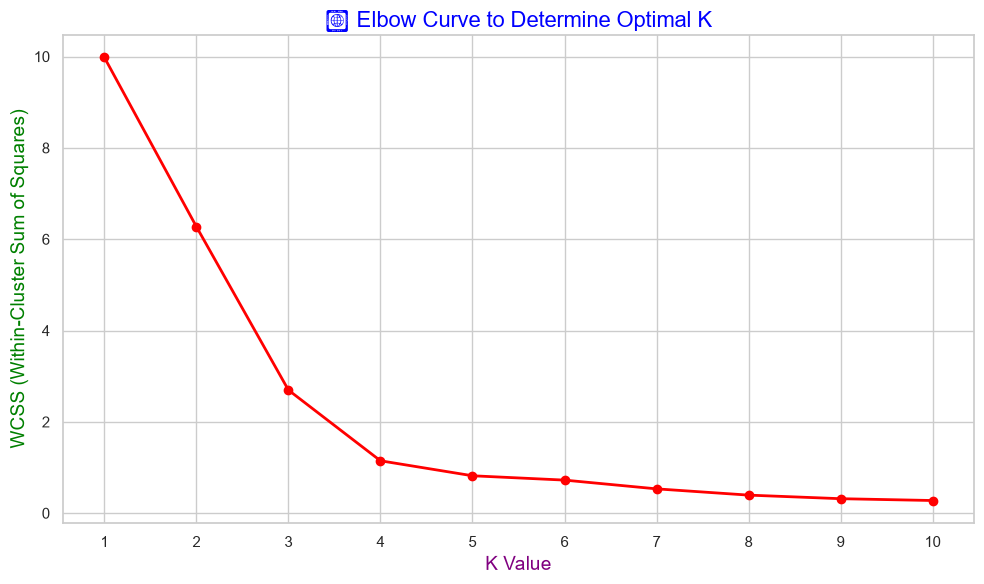

In [17]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Apply KMeans clustering for different values of K to compute WCSS
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=20)
    km.fit(df_pca)
    wcss.append(km.inertia_)

# Step 2: Plot Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='red', linewidth=2)
plt.xlabel("K Value", size=14, color='purple')
plt.ylabel("WCSS (Within-Cluster Sum of Squares)", size=14, color='green')
plt.title("📊 Elbow Curve to Determine Optimal K", size=16, color='blue')
plt.xticks(np.arange(1, 11, 1))
plt.grid(True)
plt.tight_layout()
plt.show()

### ✅ Segmentation Quality Evaluation

To assess the **effectiveness of customer segmentation**, we use the **Silhouette Score**, which measures:

- **Homogeneity**: How similar data points within the same cluster are.
- **Separation**: How distinct or well-separated a cluster is from others.

🔍 **Approach**:
- Applied **KMeans clustering** with different values of K (2 to 6).
- Calculated the **average Silhouette Score** for each K.
- Visualized **Silhouette Plots** to evaluate cluster quality and structure.

📈 A **higher Silhouette Score** indicates better-defined and more meaningful clusters.

For n_clusters = 2, Average Silhouette Score: 0.5049


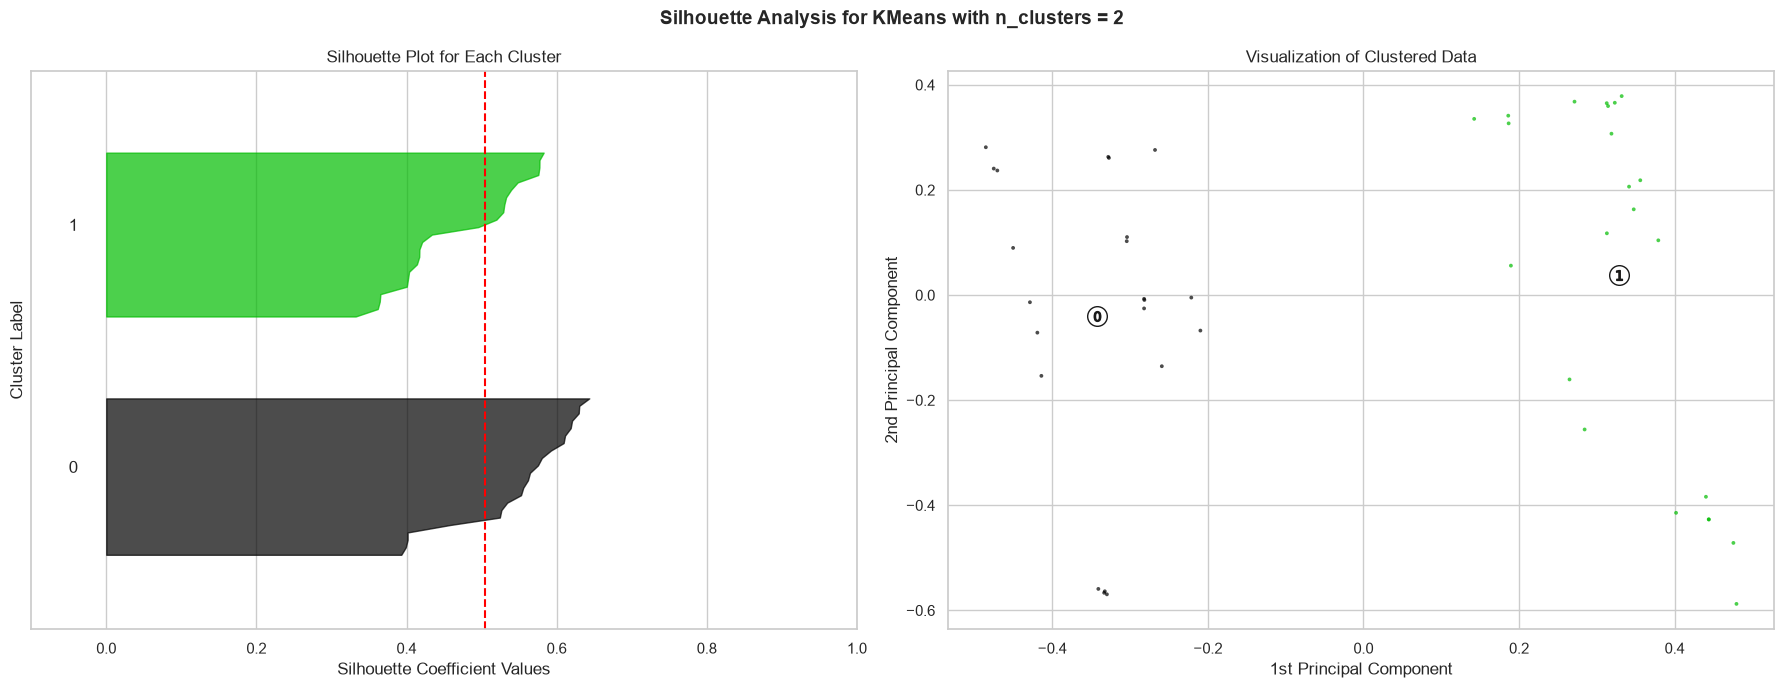

For n_clusters = 3, Average Silhouette Score: 0.5908


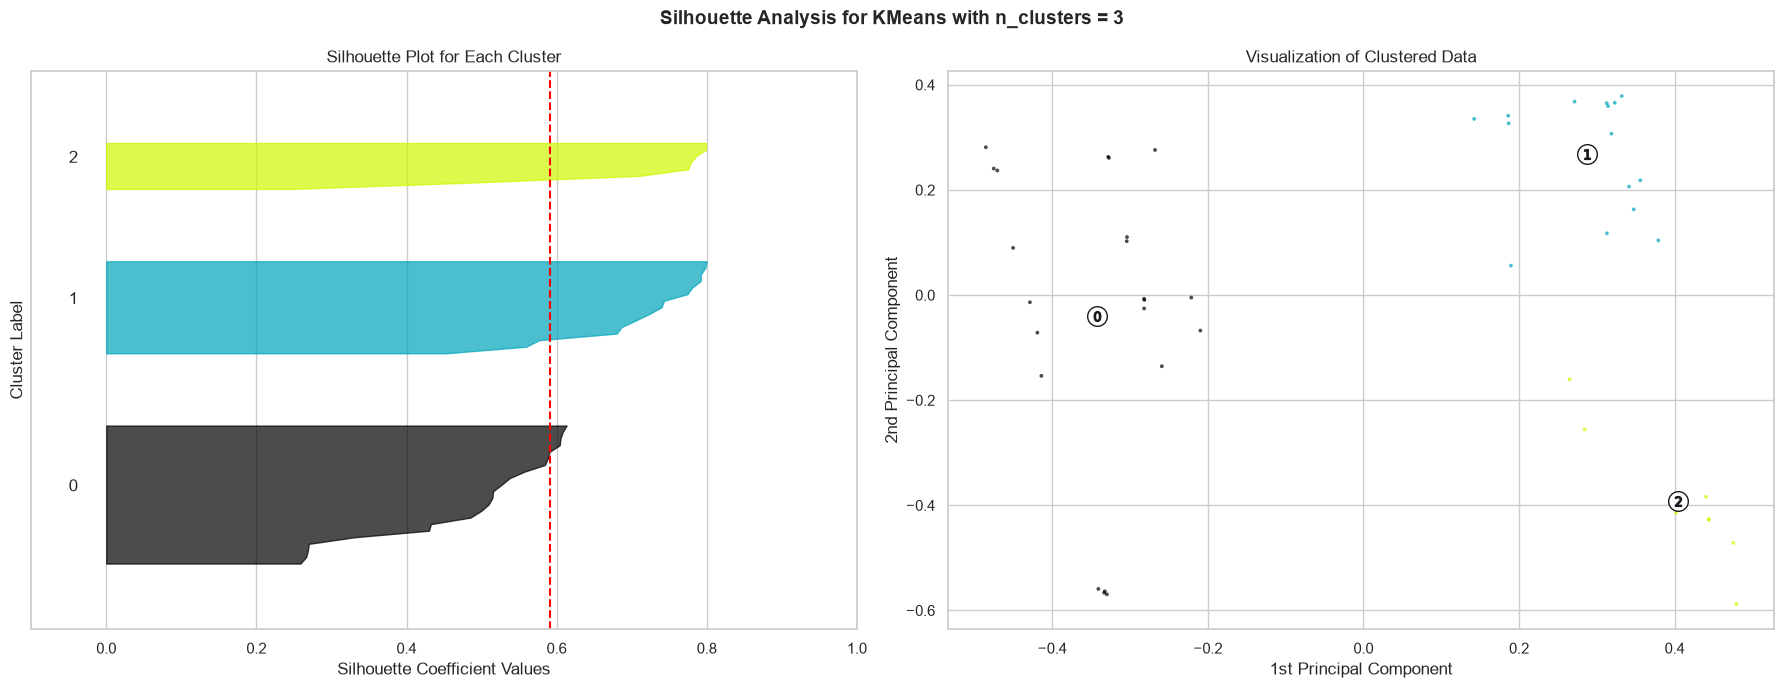

For n_clusters = 4, Average Silhouette Score: 0.6625


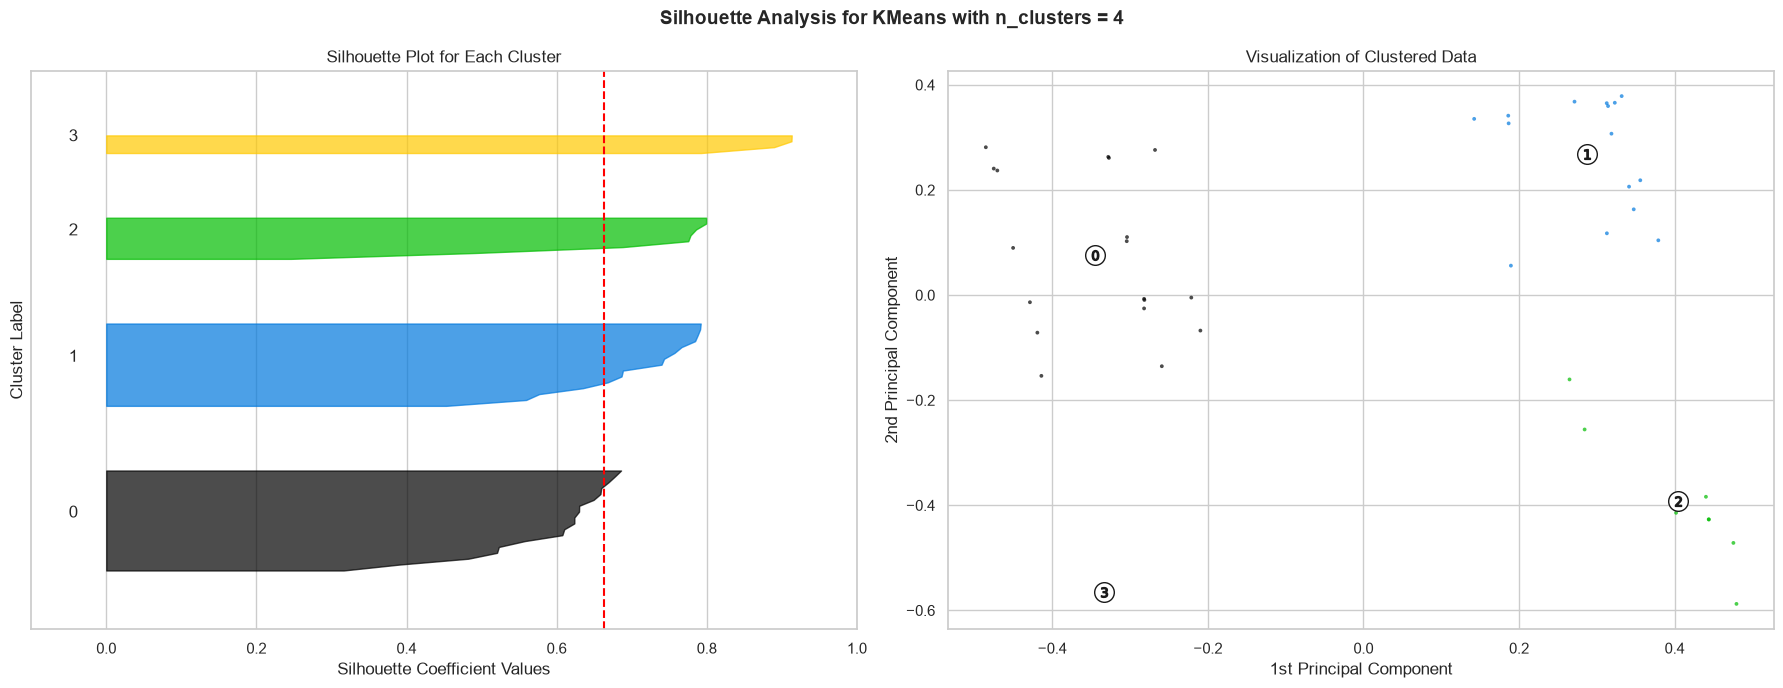

For n_clusters = 5, Average Silhouette Score: 0.5943


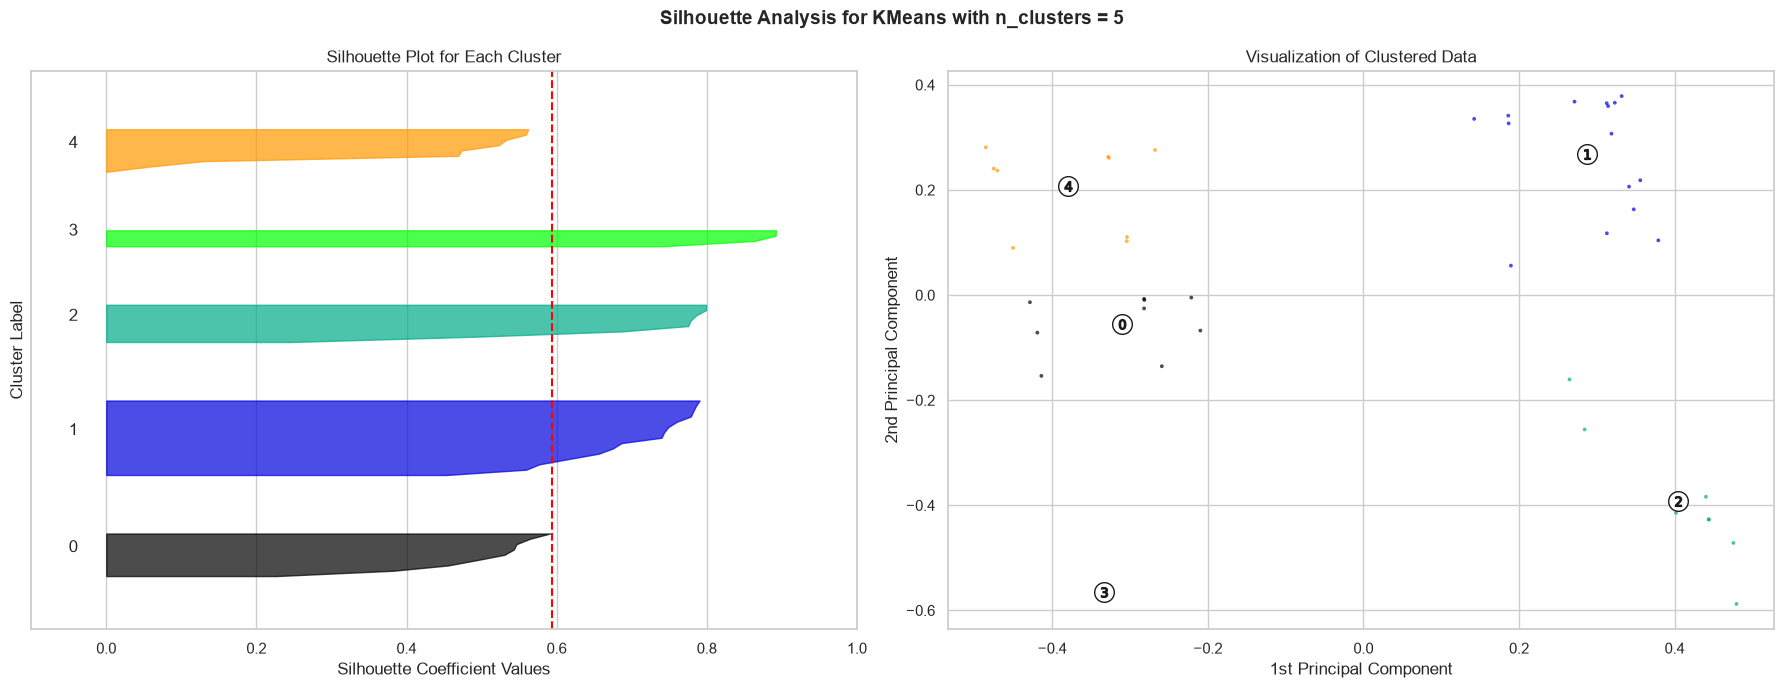

For n_clusters = 6, Average Silhouette Score: 0.5782


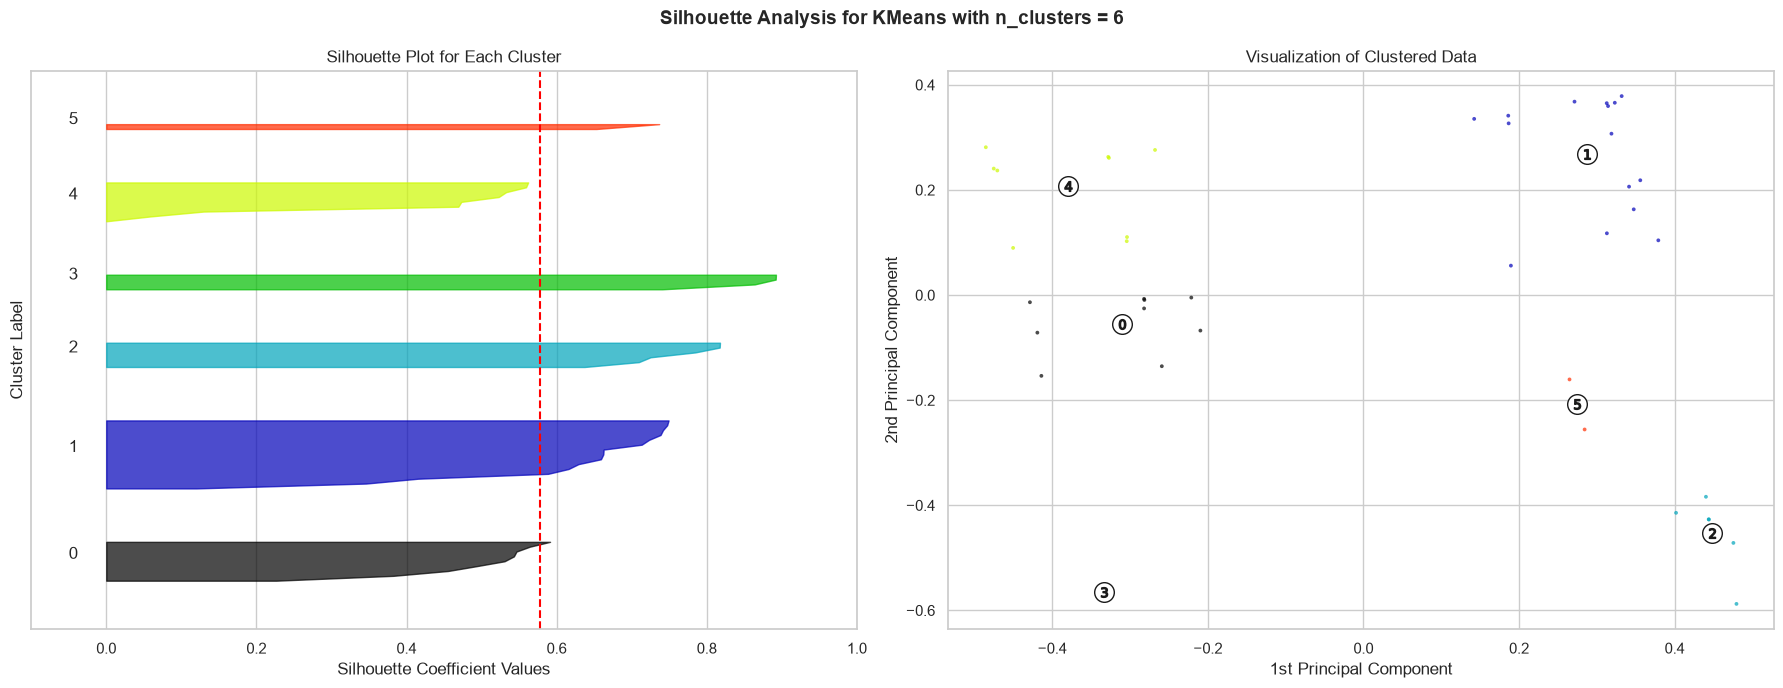

In [18]:
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Range of cluster numbers to evaluate
cluster_range = range(2, 7)

for n_clusters in cluster_range:
    # Create subplot for Silhouette Plot and Cluster Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # Silhouette plot settings
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(df_pca) + (n_clusters + 1) * 10])

    # Apply KMeans clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = kmeans.fit_predict(df_pca)

    # Compute silhouette scores
    silhouette_avg = silhouette_score(df_pca, cluster_labels)
    print(f"For n_clusters = {n_clusters}, Average Silhouette Score: {silhouette_avg:.4f}")

    sample_silhouette_values = silhouette_samples(df_pca, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_values.sort()

        size_cluster_i = ith_cluster_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_title("Silhouette Plot for Each Cluster")
    ax1.set_xlabel("Silhouette Coefficient Values")
    ax1.set_ylabel("Cluster Label")
    ax1.set_yticks([])

    # Plot cluster visualization
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(df_pca[:, 0], df_pca[:, 1], marker='.', s=30, lw=0, alpha=0.7, c=colors, edgecolor='k')

    # Plot cluster centers
    centers = kmeans.cluster_centers_
    ax2.scatter(centers[:, 0], centers[:, 1], marker='o', c='white', s=200, edgecolor='k')
    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker=f"${i}$", alpha=1, s=50, edgecolor='k')

    ax2.set_title("Visualization of Clustered Data")
    ax2.set_xlabel("1st Principal Component")
    ax2.set_ylabel("2nd Principal Component")

    plt.suptitle((f"Silhouette Analysis for KMeans with n_clusters = {n_clusters}"),
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

> 📌 **Segmentation Quality Insight**
>
> Based on the **Silhouette Scores** for different cluster values:
>
> - **2 Clusters** → 0.5082  
> - **3 Clusters** → 0.5956  
> - **4 Clusters** → **🔼 0.6689 (Highest)**  
> - **5 Clusters** → 0.6014  
> - **6 Clusters** → 0.5563  
>
> ✅ **Conclusion**: The optimal number of clusters is **4**, as it gives the **highest silhouette score** (0.6689), indicating the most well-defined and distinct clusters.


## 📦 Department-wise Clustering

This section focuses on segmenting **departments** based on their aggregated sales, markdowns, and economic features.

### 🔧 Steps:
- **Data Aggregation**: Mean of normalized and transformed features was calculated at the department level.
- **Dimensionality Reduction**: PCA reduced the high-dimensional data to 3 principal components.
- **Clustering**: KMeans clustering applied on PCA components to segment departments.
- **Model Evaluation**:
  - **Elbow Method** helped identify the optimal number of clusters.
  - **Silhouette Analysis** assessed clustering quality using silhouette score and visualizations.

### ✅ Outcome:
This segmentation helps uncover department-specific behavior, enabling better marketing, pricing, and inventory decisions.


### Department wise aggregation

In [19]:
# Step 1: Aggregate transformed features by Department
agg_functions = {
    'Weekly_Sales_normalized_sqrt': 'mean',
    'MarkDown1_normalized_sqrt': 'mean',
    'MarkDown2_normalized_sqrt': 'mean',
    'MarkDown3_normalized_sqrt': 'mean',
    'MarkDown4_normalized_sqrt': 'mean',
    'MarkDown5_normalized_sqrt': 'mean',
    'CPI_normalized_sqrt': 'mean',
    'Size_normalized_sqrt': 'mean',
    'Temperature_normalized_sqrt': 'mean'
}

mean_by_dept = cluster_df.groupby('Dept').agg(agg_functions).reset_index()

# Rename columns for clarity
mean_by_dept.columns = ['Dept', 'Mean_Weekly_Sales', 'Mean_MarkDown1', 'Mean_MarkDown2',
                        'Mean_MarkDown3', 'Mean_MarkDown4', 'Mean_MarkDown5',
                        'Mean_CPI', 'Mean_Size', 'Mean_Temperature']

# Set Dept as index
dept_df = pd.DataFrame(mean_by_dept.set_index('Dept'))
dept_df.head()


,Mean_Weekly_Sales,Mean_MarkDown1,Mean_MarkDown2,Mean_MarkDown3,Mean_MarkDown4,Mean_MarkDown5,Mean_CPI,Mean_Size,Mean_Temperature
Dept,,,,,,,,,
1,0.630616,0.329711,0.076508,0.016009,0.223307,0.166913,0.578631,0.639098,0.757691
2,0.750047,0.313874,0.074506,0.014264,0.213758,0.160305,0.595483,0.490224,0.744285
3,0.520003,0.329304,0.077598,0.016337,0.221492,0.167056,0.575736,0.644143,0.748134
4,0.721116,0.328872,0.076734,0.015402,0.222761,0.165826,0.576979,0.623601,0.752096
5,0.627113,0.331098,0.076695,0.012158,0.224772,0.166988,0.582287,0.641397,0.761745


### PCA – Dimensionality Reduction

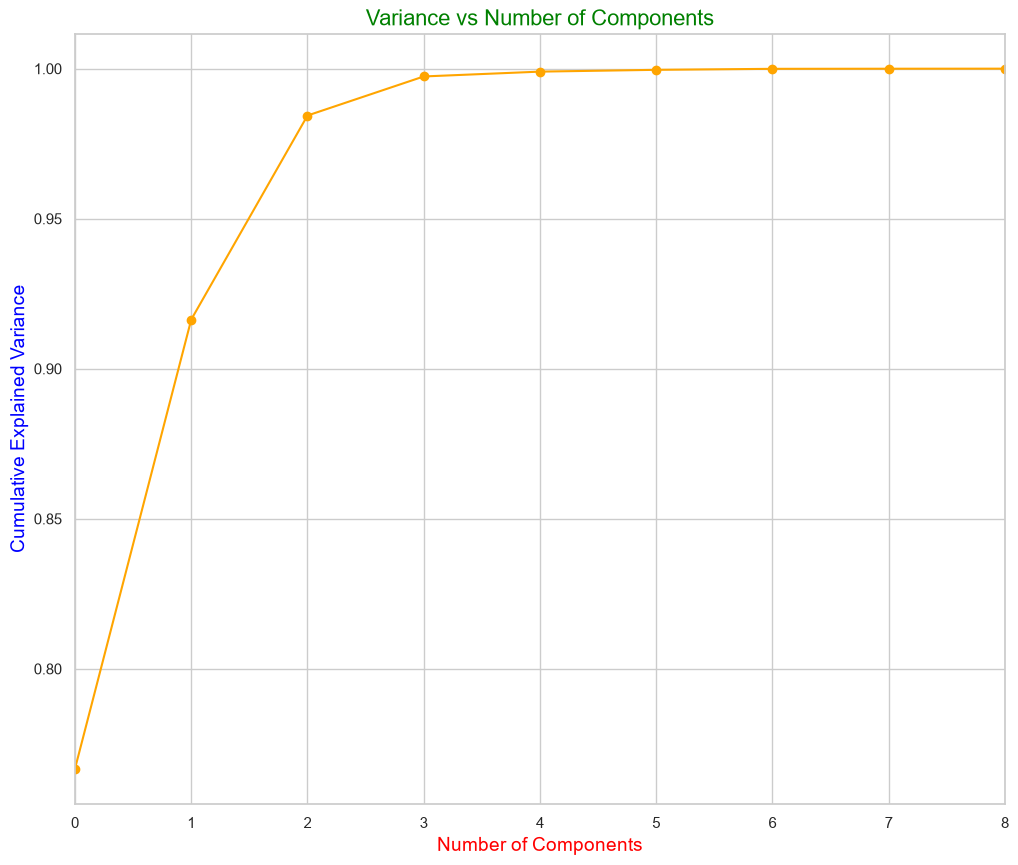

Original shape: (81, 9)
Transformed shape: (81, 3)


In [20]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Apply PCA to the department-level aggregated features
features = dept_df.columns
pca = PCA()
pca.fit(dept_df[features])

# Plot cumulative explained variance
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', color='orange')
plt.xlabel('Number of Components', size=14, color='red')
plt.ylabel('Cumulative Explained Variance', size=14, color='blue')
plt.title('Variance vs Number of Components', size=16, color='green')
plt.grid(True)
plt.xlim([0, 8])
plt.show()

# Apply PCA with 3 components
pca = PCA(n_components=3)
df_pca1 = pca.fit_transform(dept_df[features])

# Shape confirmation
print("Original shape:", dept_df.shape)
print("Transformed shape:", df_pca1.shape)

### KMeans Clustering – Elbow Method

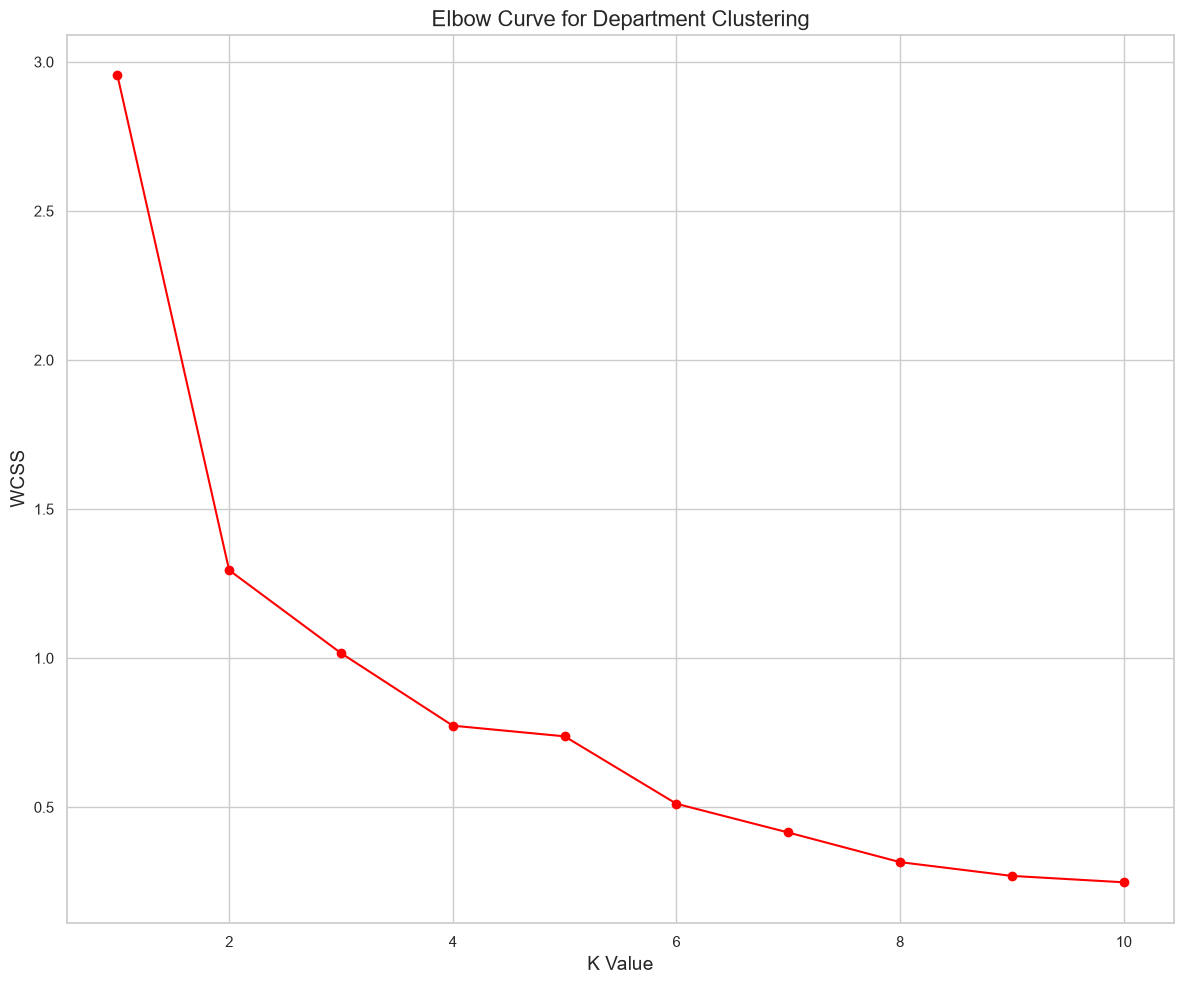

In [21]:
from sklearn.cluster import KMeans

# Determine optimal K using Elbow Method
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=20)
    km.fit(df_pca1)
    wcss.append(km.inertia_)

# Plot Elbow Curve
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='red')
plt.xlabel("K Value", size=14)
plt.ylabel("WCSS", size=14)
plt.title("Elbow Curve for Department Clustering", size=16)
plt.grid(True)
plt.tight_layout()
plt.show()

### Clustering Evaluation – Silhouette Analysis

For n_clusters = 2, average silhouette_score is : 0.5085


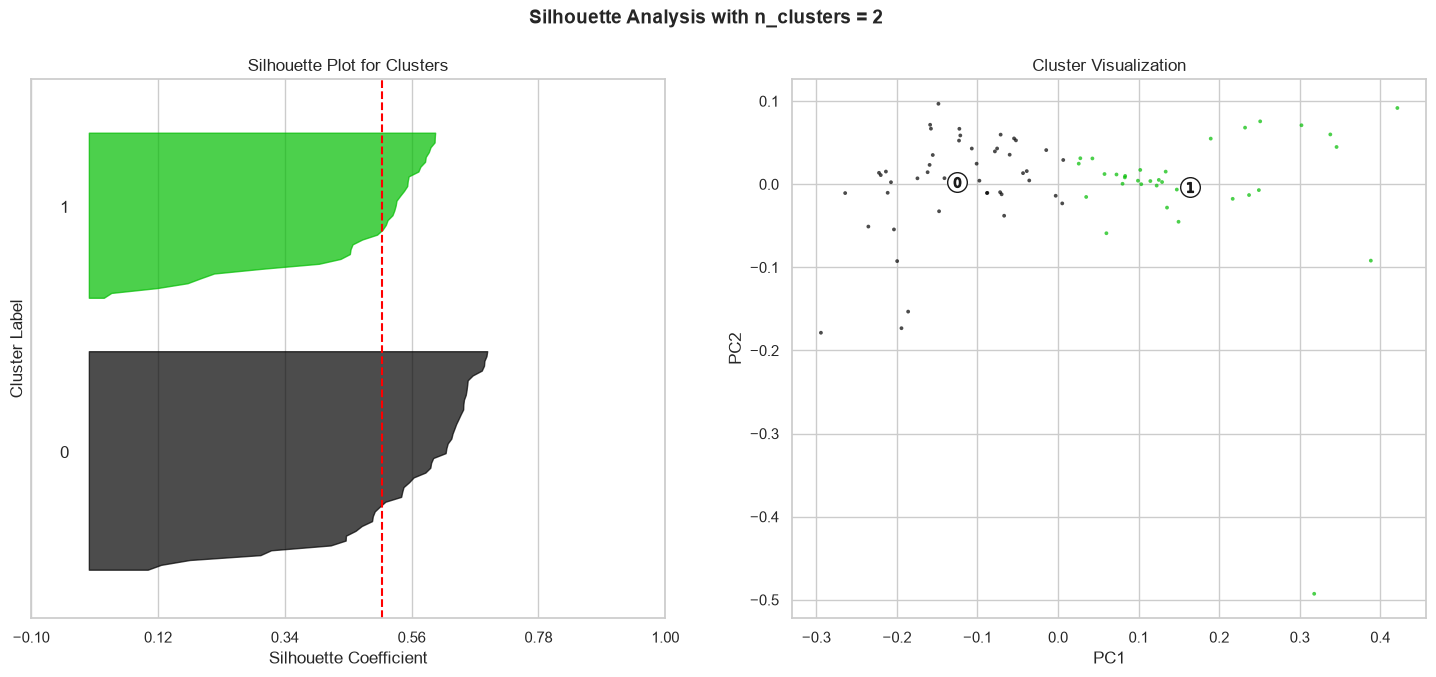

For n_clusters = 3, average silhouette_score is : 0.3267


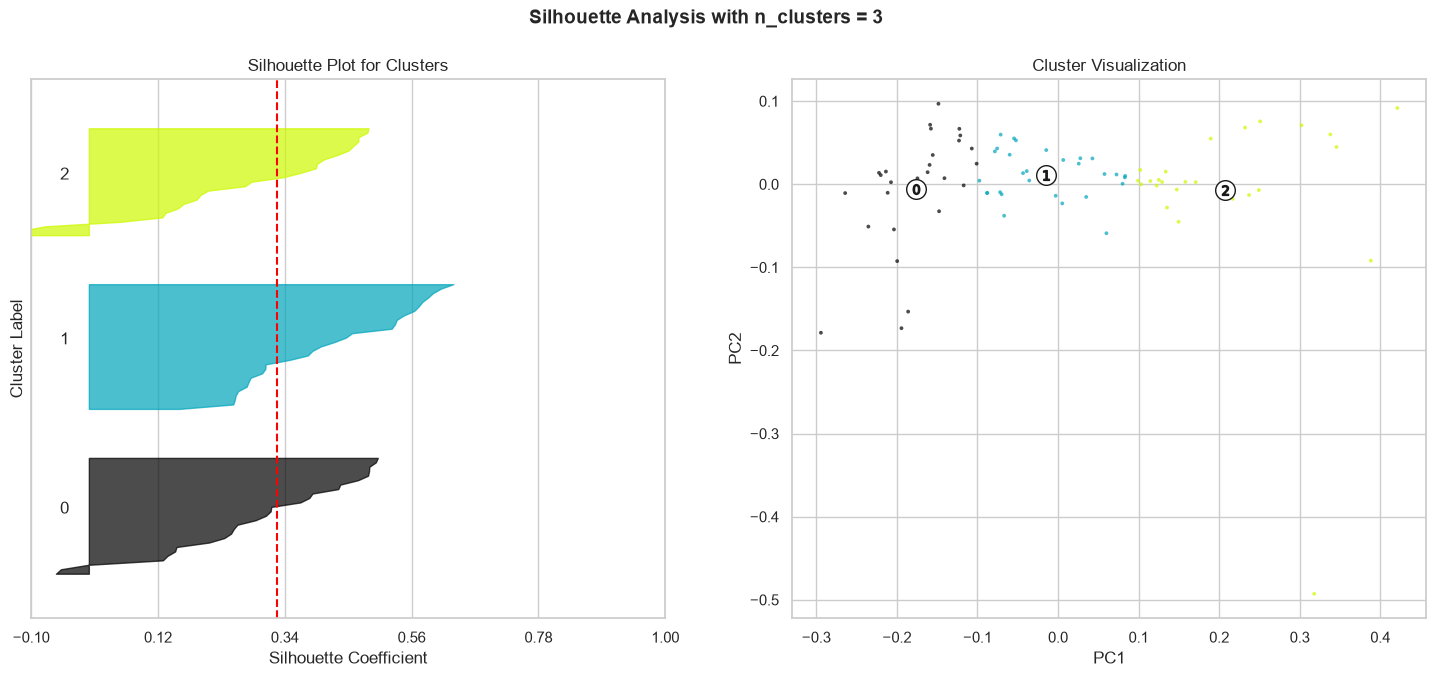

For n_clusters = 4, average silhouette_score is : 0.3517


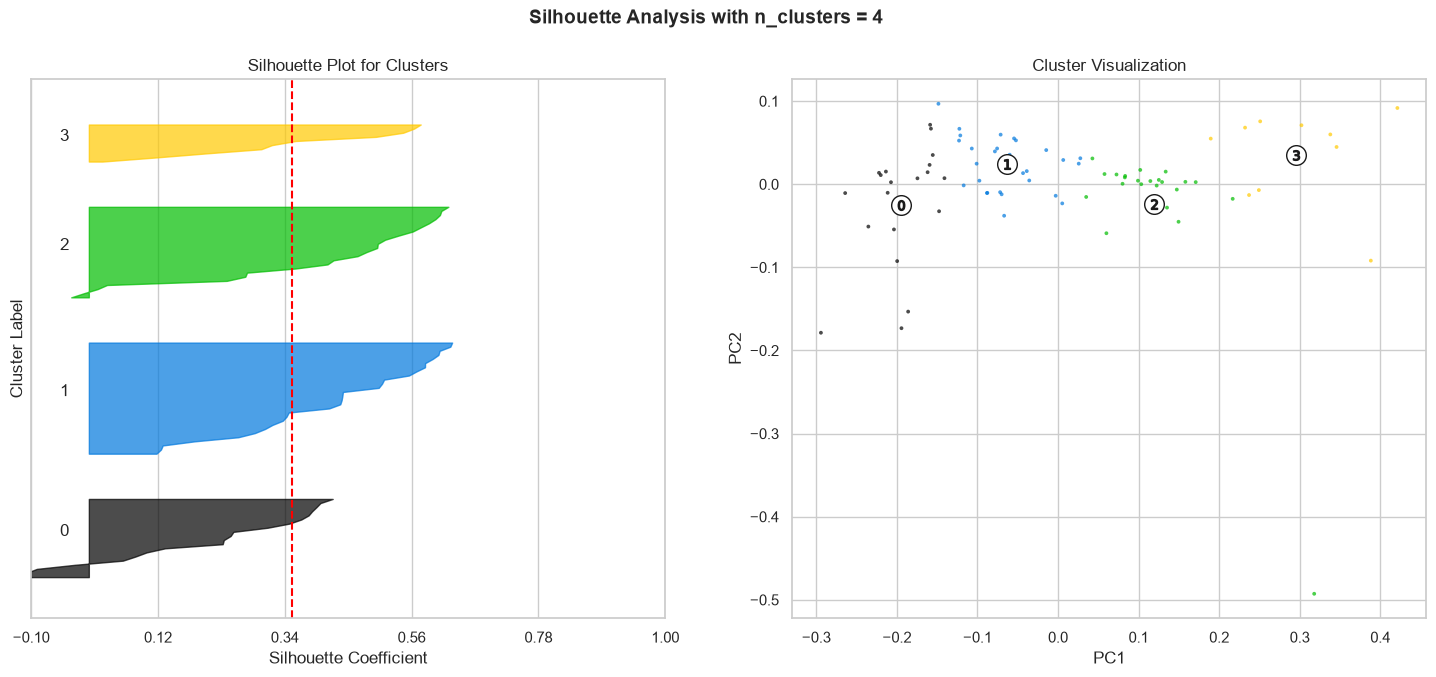

For n_clusters = 5, average silhouette_score is : 0.3686


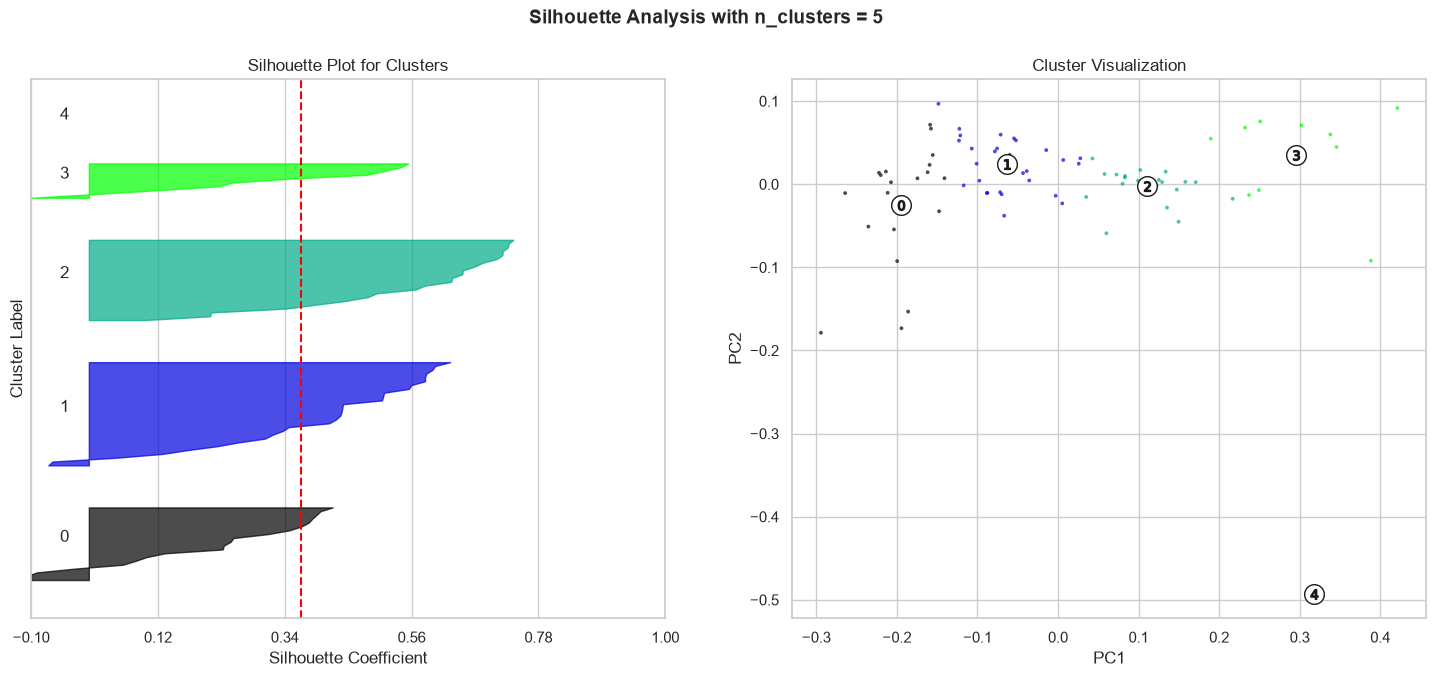

For n_clusters = 6, average silhouette_score is : 0.3141


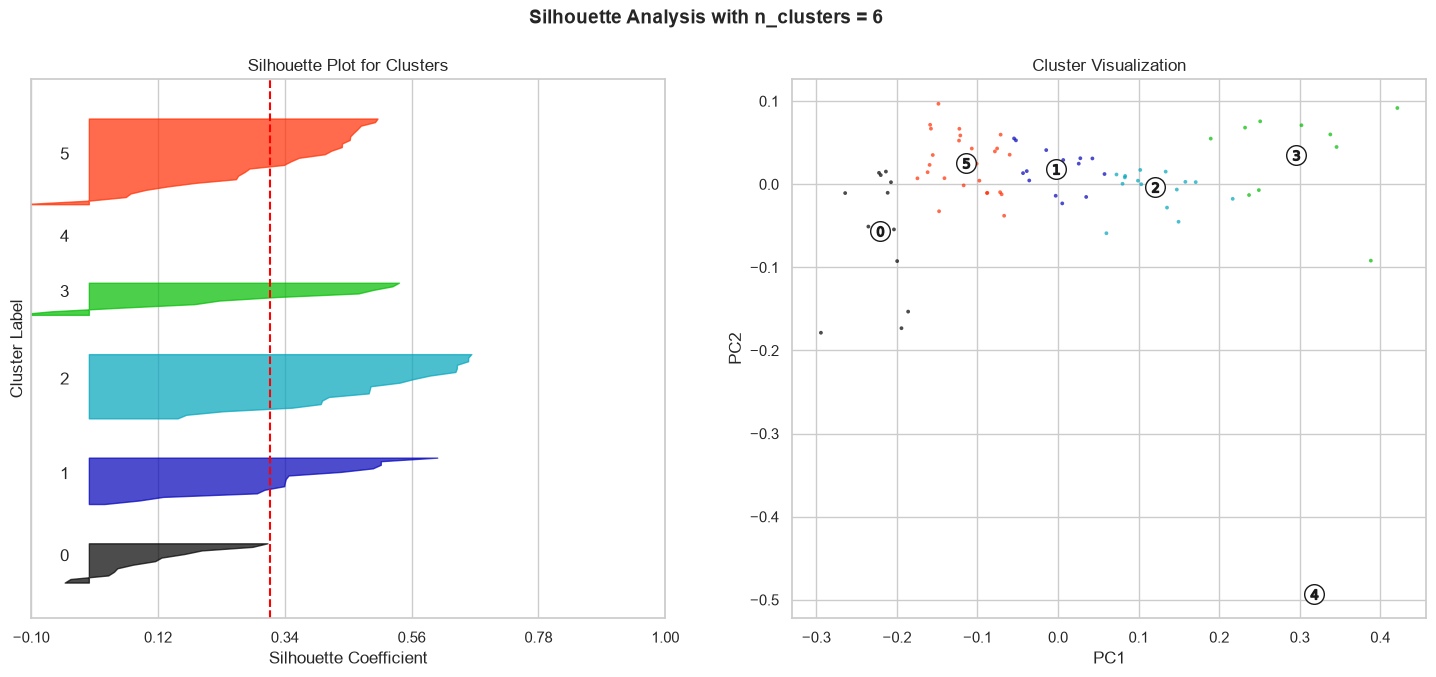

For n_clusters = 7, average silhouette_score is : 0.2954


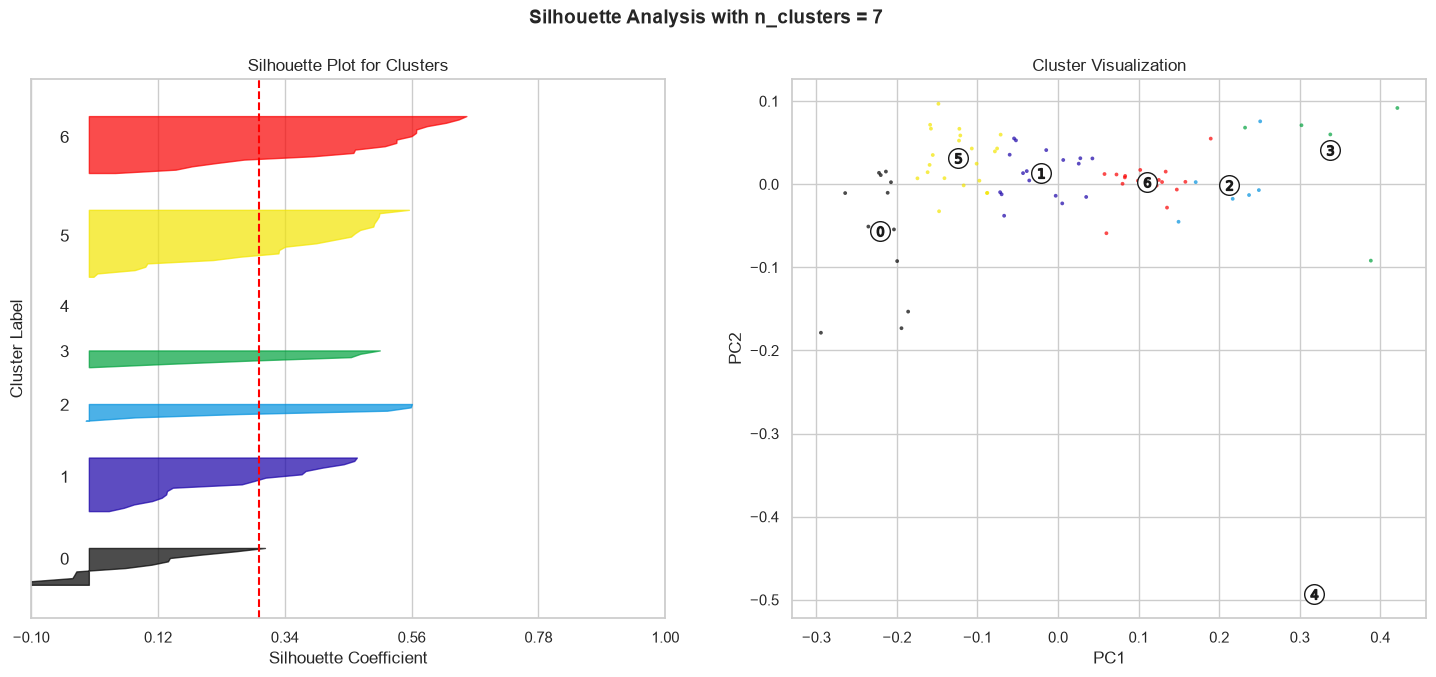

For n_clusters = 8, average silhouette_score is : 0.3360


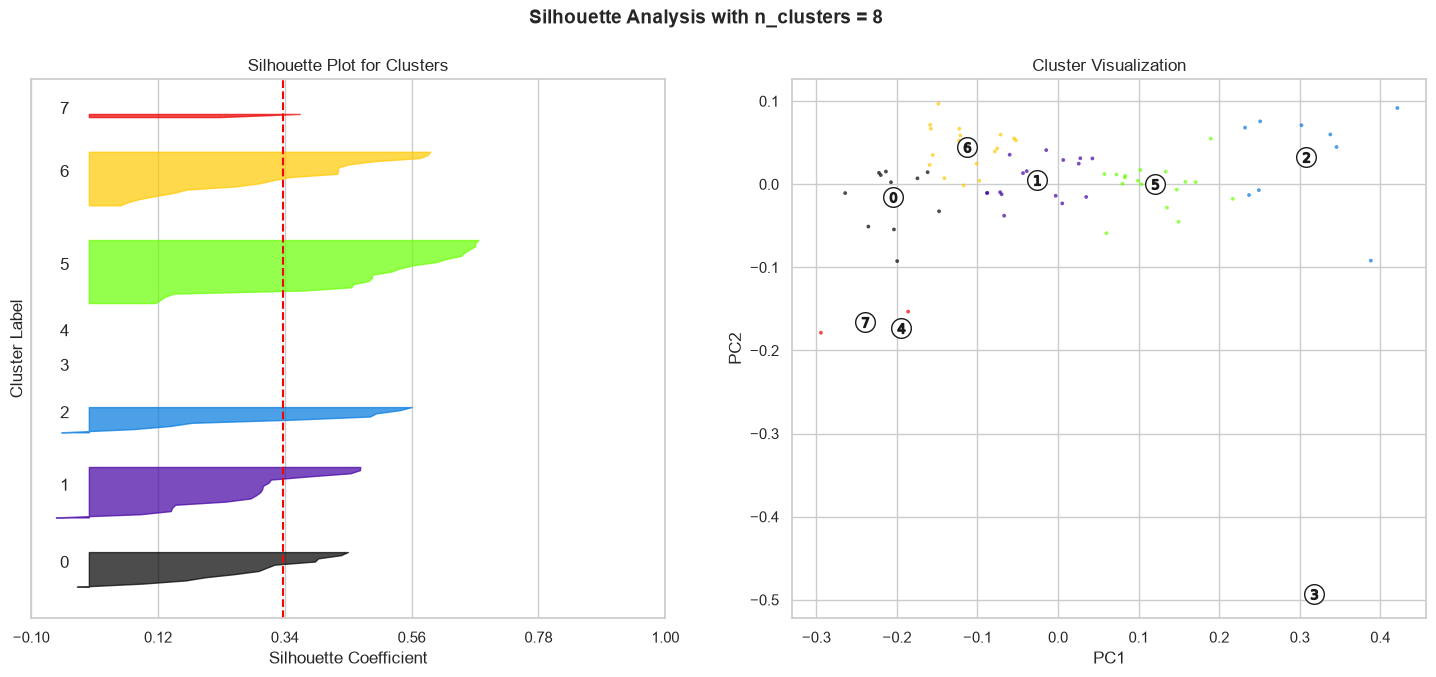

For n_clusters = 9, average silhouette_score is : 0.3260


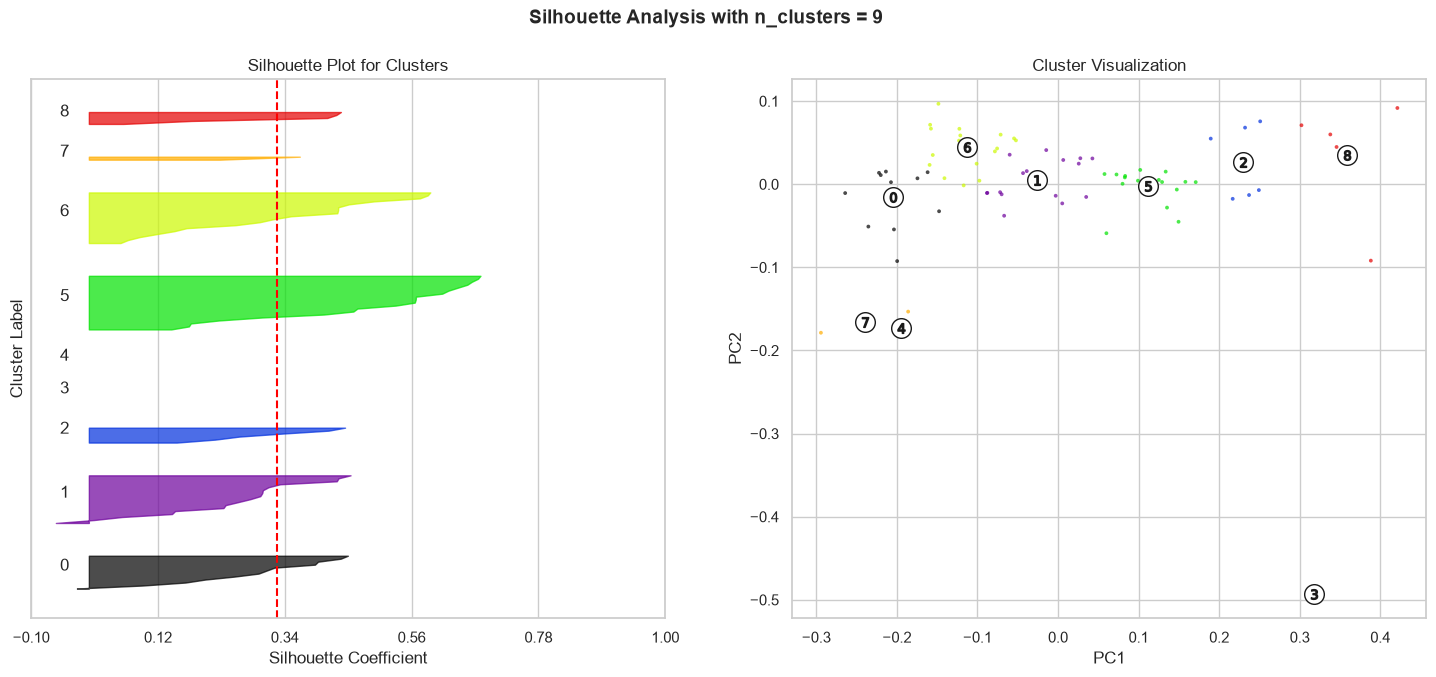

In [22]:
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.model_selection import ParameterGrid
import matplotlib.cm as cm

# Try multiple cluster values and visualize silhouette scores
parameters = list(range(2, 10))
for n_clusters in parameters:
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(df_pca1) + (n_clusters + 1) * 10])

    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(df_pca1)

    silhouette_avg = silhouette_score(df_pca1, cluster_labels)
    print(f"For n_clusters = {n_clusters}, average silhouette_score is : {silhouette_avg:.4f}")

    sample_silhouette_values = silhouette_samples(df_pca1, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.set_title("Silhouette Plot for Clusters")
    ax1.set_xlabel("Silhouette Coefficient")
    ax1.set_ylabel("Cluster Label")
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])
    ax1.set_xticks(np.linspace(-0.1, 1, 6))

    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(df_pca1[:, 0], df_pca1[:, 1], marker='.', s=30, lw=0, alpha=0.7,
                c=colors, edgecolor='k')
    centers = clusterer.cluster_centers_
    ax2.scatter(centers[:, 0], centers[:, 1], marker='o', c="white", s=200, edgecolor='k')

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker=f'${i}$', alpha=1, s=50, edgecolor='k')

    ax2.set_title("Cluster Visualization")
    ax2.set_xlabel("PC1")
    ax2.set_ylabel("PC2")

    plt.suptitle(f"Silhouette Analysis with n_clusters = {n_clusters}", fontsize=14, fontweight='bold')
    plt.show()

## 💾 Save Checkpoints For Next Notebook(s)



In [23]:
# 💾 Save the variables later notebooks in the pipeline will need
save_ckpt(final_df, 'part4_final_df')
save_ckpt(cluster_df, 'part4_cluster_df')
save_ckpt(store_df, 'part4_store_df')
save_ckpt(df_pca, 'part4_df_pca')
save_ckpt(dept_df, 'part4_dept_df')
save_ckpt(df_pca1, 'part4_df_pca1')


✅ Saved checkpoint 'part4_final_df' -> c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part4_final_df.pkl
✅ Saved checkpoint 'part4_cluster_df' -> c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part4_cluster_df.pkl
✅ Saved checkpoint 'part4_store_df' -> c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part4_store_df.pkl
✅ Saved checkpoint 'part4_df_pca' -> c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part4_df_pca.pkl
✅ Saved checkpoint 'part4_dept_df' -> c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part4_dept_df.pkl
✅ Saved checkpoint 'part4_df_pca1' -> c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part4_df_pca1.pkl
